# Day 114 — Cross-Validation: KFold + StratifiedKFold
**Month 6 | Week 6 | Day 1 | 80 Points + 10★ Bonus**

---

## The Problem With a Single Train/Test Split

Every model you have built so far (Days 107–113) used this pattern:

```python
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
model.fit(X_train)
score = model.score(X_test)          # ← one number from one split
```

**The hidden flaw:** this number depends entirely on which 60 rows happened to fall in the test set. Run `random_state=0` — different number. Run `random_state=99` — another number. You are reporting an estimate with unknown uncertainty.

Cross-validation fixes this. It runs the evaluation k times on k different splits and lets you report:  
*"F1 = 0.77 ± 0.07 across 5 stratified folds."*  
That statement is defensible in front of a CTO. A single split number is not.

| Property | Single Split | Cross-Validation |
|----------|-------------|------------------|
| Evaluations | 1 | k (typically 5 or 10) |
| Score reliability | Low | High |
| Overfitting visible? | ❌ No | ✅ Train vs Test gap |
| Industry standard | Prototyping only | ✅ Production + papers |

---

## Business Scenario

You deliver your churn model to the ShopEase ML lead. They reply:

> *"Your model shows F1 = 0.82. But is that reproducible — or did you just get lucky with one split? Our churn data is also imbalanced (~24%). Does your evaluation even have the right class ratio in each split? I need a number I can stand behind in the board meeting."*

These are three concerns: **reliability, reproducibility, class distribution per fold.** Today's workflow answers all three.


---
## Section 1 — Raw Data (Do Not Modify)

In [1]:
# ── SECTION 1: RAW DATA — DO NOT MODIFY ──────────────────────────────────────
# ShopEase Customer Churn Dataset — 300 rows, seed=42
# Features correspond to customer behaviour metrics
# Churn label: 1 = churned within 90 days, 0 = retained

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_validate, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import make_classification

# Generate dataset with known signal structure (5 informative features)
X_raw, y_raw = make_classification(
    n_samples=300, n_features=8, n_informative=5, n_redundant=2,
    n_clusters_per_class=1, weights=[0.78, 0.22], flip_y=0.05,
    random_state=42
)

# Map to ShopEase business feature names
feature_names = [
    'days_since_last', 'total_orders', 'avg_order_value',
    'session_count', 'return_rate', 'num_categories',
    'tenure_months', 'age'
]

df = pd.DataFrame(X_raw, columns=feature_names)
df['Churn'] = y_raw

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.1%}  ({df['Churn'].sum()} churned / {(~df['Churn'].astype(bool)).sum()} retained)")
print()
print(df.head(5).round(3).to_string())


Dataset shape: (300, 9)
Churn rate: 24.0%  (72 churned / 228 retained)

   days_since_last  total_orders  avg_order_value  session_count  return_rate  num_categories  tenure_months    age  Churn
0            0.422        -0.456            1.648         -1.665       -3.141           0.784         -1.049  1.913      0
1           -0.103         2.697            0.162          1.619        5.779          -2.413         -4.009  0.756      0
2            2.291         1.722            1.443          2.356        4.361          -0.857         -2.540  0.447      0
3           -0.888         1.231           -1.684          0.219        1.200           0.075          0.374 -0.584      1
4            0.104         0.653            0.700         -1.194       -1.163           0.851         -0.680 -0.596      1


---
## Section 2 — Concept Notes

### How KFold Works

```
Full dataset (300 rows), KFold(5):
┌────────────────────────────────────────────────────────────┐
│ Fold 1: [TEST 60 ] [TRAIN ─────────────────────── 240]    │ → score_1
│ Fold 2: [TRAIN 60] [TEST 60] [TRAIN ──────────── 180]    │ → score_2
│ Fold 3: [TRAIN 120────────] [TEST 60] [TRAIN ──── 120]   │ → score_3
│ Fold 4: [TRAIN 180────────────────] [TEST 60] [TR 60]    │ → score_4
│ Fold 5: [TRAIN 240──────────────────────────────][TEST60] │ → score_5
└────────────────────────────────────────────────────────────┘
  Final: mean([s1…s5]) ± std([s1…s5])
```

Every row is used **exactly once for testing** and 4 times for training.

---

### KFold vs StratifiedKFold

| | KFold | StratifiedKFold |
|---|---|---|
| Split method | Random rows | Preserves class ratio per fold |
| Risk without it | Fold may have 0 churned customers | Each fold reflects true 24% churn |
| When to use | Regression | ✅ Any classification |
| sklearn class | `KFold` | `StratifiedKFold` |

**Rule:** Default to `StratifiedKFold` for all classification tasks.

---

### cross_val_score vs cross_validate

```python
# Returns array of scores (one metric)
scores = cross_val_score(model, X, y, cv=skf, scoring='f1')
print(f"F1: {scores.mean():.3f} ± {scores.std():.3f}")

# Returns dict of arrays (multiple metrics + train scores)
results = cross_validate(model, X, y, cv=skf,
                         scoring=['accuracy', 'f1', 'roc_auc'],
                         return_train_score=True)
# Access: results['test_f1'], results['train_f1'], etc.
```

`cross_validate` is almost always better — same compute, more insight.

---

### Detecting Overfitting via Train/Test Gap

```
Train F1 = 1.00,  Test F1 = 0.55  → Severe overfitting  (complex tree model)
Train F1 = 0.80,  Test F1 = 0.74  → Moderate overfitting (normal for RF)
Train F1 = 0.78,  Test F1 = 0.76  → Well-generalised    (ideal)
Train F1 = 0.52,  Test F1 = 0.51  → Underfitting        (too simple)
```

The train-test gap is the most important diagnostic in production ML.

---

### The Correct Reporting Format

```python
# ❌ Weak — single number, no uncertainty
print(f"F1: {score:.3f}")

# ✅ Strong — mean ± std, industry standard
print(f"F1: {scores.mean():.3f} ± {scores.std():.3f}")
```


---
## Section 3 — Practice Guide

**Rules:**
1. Write a plain-English comment above each code block explaining your goal
2. `savefig()` before `plt.show()` always
3. NRA must use computed numbers from your own output — not guesses
4. Do not modify Section 1

---

### Part A — Setup + Baseline (15 pts)

**A1 (5 pts):** Prepare `X` (all 8 features) and `y` (Churn). Scale with `StandardScaler`. Print shape and confirm the churn rate is preserved after scaling.

**A2 (5 pts):** Build a baseline with a **single train/test split** (`test_size=0.2, random_state=42`). Fit `LogisticRegression(max_iter=1000)`. Print Accuracy, F1, and ROC-AUC.

**A3 (5 pts):** Print the churn rate in `y_train` and `y_test`. Are they consistent with the overall rate? Answer yes/no with the three numbers.

---

### Part B — KFold Cross-Validation (20 pts)

**B1 (7 pts):** Run `cross_val_score` with `KFold(n_splits=5, shuffle=True, random_state=42)` on LogisticRegression, `scoring='f1'`. Print all 5 fold scores and `mean ± std`.

**B2 (7 pts):** Repeat with `KFold(n_splits=10, shuffle=True, random_state=42)`. Print `mean ± std`. Which has lower std — 5-fold or 10-fold? Print a two-sentence comparison.

**B3 (6 pts):** Use `cross_validate` with `KFold(5)` to get both `train_f1` and `test_f1`. Print both. State the train-test gap and your overfitting verdict.

---

### Part C — StratifiedKFold (15 pts)

**C1 (5 pts):** Run `cross_val_score` with `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` on LogisticRegression, `scoring='f1'`. Print mean ± std.

**C2 (5 pts):** Inside the StratifiedKFold loop (`skf.split(X, y)`), print the churn rate in each fold's test set. Confirm all 5 stay within ±3% of overall churn rate.

**C3 (5 pts):** Print a comparison table: KFold(5) vs StratifiedKFold(5) — mean F1 and std. State which to use and why (one sentence citing the imbalance).

---

### Part D — cross_validate: Multi-Metric (15 pts)

**D1 (8 pts):** Using `cross_validate` with `StratifiedKFold(5)`, evaluate LogisticRegression on: `accuracy`, `f1`, `roc_auc`. Set `return_train_score=True`. Print a table showing `mean ± std` for both train and test on all three metrics.

**D2 (7 pts):** Add `RandomForestClassifier(n_estimators=100, random_state=42)`. Run the same `cross_validate` call. Print a **side-by-side table**: LR vs RF across all three test metrics. Mark the winner per metric.

---

### Part E — Model Comparison + NRA (15 pts)

**E1 (8 pts):** Add `XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)`. Evaluate all three models with `cross_validate` + `StratifiedKFold(5)`. Print a summary table: model × metric, sorted by test F1 descending.

**E2 (7 pts — NRA):** Write a business recommendation:

> **Number:** [cite the best model's CV F1 mean ± std]  
> **Reason:** [why F1 is the right metric for this imbalanced churn data]  
> **Action:** [which model to deploy, plus one monitoring condition referencing the std]

---

### ★ Bonus — Learning Curve (10★)

**B★:** Plot a learning curve for `RandomForestClassifier` using `sklearn.model_selection.learning_curve`. Show both train and CV F1 lines. Title must state a business insight about whether more data is needed. Save to `Day114_LearningCurve.png`.


---
## Section 4 — Answer Key
*Complete all tasks before reading this section.*

In [2]:
# =============================================================================
# TASK A1 – Prepare X and y, scale features
# Goal: Extract features and target, standardise numeric features.
# Method: Select all columns except 'Churn' as features, apply StandardScaler.
# =============================================================================

features = ['days_since_last', 'total_orders', 'avg_order_value',
            'session_count', 'return_rate', 'num_categories',
            'tenure_months', 'age']

X = df[features].values
y = df['Churn'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("A1 – Dataset after scaling:")
print(f"  X shape      : {X_scaled.shape}")
print(f"  y shape      : {y.shape}")
print(f"  Overall churn rate: {y.mean():.3f} ({y.sum()} churned / {(~y.astype(bool)).sum()} retained)")
print("  Scaling does not affect class distribution.")

A1 – Dataset after scaling:
  X shape      : (300, 8)
  y shape      : (300,)
  Overall churn rate: 0.240 (72 churned / 228 retained)
  Scaling does not affect class distribution.


In [3]:
# =============================================================================
# TASK A2 – Baseline with single split (random_state=42)
# Goal: Get one-time estimates of accuracy, F1, and ROC-AUC.
# Method: train_test_split with test_size=0.2, fit LogisticRegression.
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("A2 – Baseline (single split, random_state=42):")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\n  ⚠️ This is ONE number from ONE split – not reliable.")

A2 – Baseline (single split, random_state=42):
  Accuracy : 0.9167
  F1       : 0.7619
  ROC-AUC  : 0.9574

  ⚠️ This is ONE number from ONE split – not reliable.


In [4]:
# =============================================================================
# TASK A3 – Compare churn rate in train and test splits
# Goal: Check if single split preserves the overall imbalance.
# Method: Print means of y_train and y_test.
# =============================================================================

print("A3 – Churn rate distribution:")
print(f"  Overall  : {y.mean():.4f}")
print(f"  y_train  : {y_train.mean():.4f}  (n={len(y_train)})")
print(f"  y_test   : {y_test.mean():.4f}  (n={len(y_test)})")

train_dev = abs(y_train.mean() - y.mean())
test_dev = abs(y_test.mean() - y.mean())
print(f"\n  Deviation from overall: train {train_dev:.4f}, test {test_dev:.4f}")

# Markdown answer follows – write as separate cell

A3 – Churn rate distribution:
  Overall  : 0.2400
  y_train  : 0.2458  (n=240)
  y_test   : 0.2167  (n=60)

  Deviation from overall: train 0.0058, test 0.0233


### A3 – Class distribution consistency

The overall churn rate is 0.240 (24.0%). The training split has churn rate 0.2458, and the test split has 0.2167. Both are within 3 percentage points of the overall rate, so they are reasonably consistent. However, with only 20% of data in the test set (60 rows), random chance could produce a more imbalanced fold. This is why StratifiedKFold is preferred for imbalanced classification.

In [5]:
# =============================================================================
# TASK B1 – KFold with 5 splits, scoring='f1'
# Goal: Obtain 5-fold CV F1 scores and report mean ± std.
# Method: KFold(n_splits=5, shuffle=True, random_state=42), cross_val_score.
# =============================================================================

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kf5 = cross_val_score(lr, X_scaled, y, cv=kf5, scoring='f1')

print("B1 – KFold(5) F1 scores:")
for i, s in enumerate(scores_kf5, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean ± Std : {scores_kf5.mean():.4f} ± {scores_kf5.std():.4f}")

B1 – KFold(5) F1 scores:
  Fold 1: 0.7619
  Fold 2: 0.8148
  Fold 3: 0.7586
  Fold 4: 0.8462
  Fold 5: 0.5926
  Mean ± Std : 0.7548 ± 0.0875


In [6]:
# =============================================================================
# TASK B2 – KFold with 10 splits, compare std to 5-fold
# Goal: See effect of more folds on stability.
# Method: KFold(10) then compare standard deviations.
# =============================================================================

kf10 = KFold(n_splits=10, shuffle=True, random_state=42)
scores_kf10 = cross_val_score(lr, X_scaled, y, cv=kf10, scoring='f1')

print("B2 – KFold(10) F1 scores:")
for i, s in enumerate(scores_kf10, 1):
    print(f"  Fold {i:2d}: {s:.4f}")
print(f"  Mean ± Std : {scores_kf10.mean():.4f} ± {scores_kf10.std():.4f}")

print("\nB2 – Comparison (5-fold vs 10-fold):")
print(f"  KFold(5)  : {scores_kf5.mean():.4f} ± {scores_kf5.std():.4f}")
print(f"  KFold(10) : {scores_kf10.mean():.4f} ± {scores_kf10.std():.4f}")

if scores_kf10.std() < scores_kf5.std():
    print("  10-fold has lower standard deviation, meaning more stable estimate.")
else:
    print("  5-fold has lower standard deviation. This can happen due to randomness; typical behaviour is more folds → lower variance.")

B2 – KFold(10) F1 scores:
  Fold  1: 0.8000
  Fold  2: 0.8333
  Fold  3: 0.7692
  Fold  4: 0.8000
  Fold  5: 0.5000
  Fold  6: 0.8750
  Fold  7: 0.8421
  Fold  8: 0.8571
  Fold  9: 0.7059
  Fold 10: 0.4000
  Mean ± Std : 0.7383 ± 0.1528

B2 – Comparison (5-fold vs 10-fold):
  KFold(5)  : 0.7548 ± 0.0875
  KFold(10) : 0.7383 ± 0.1528
  5-fold has lower standard deviation. This can happen due to randomness; typical behaviour is more folds → lower variance.


In [7]:
# =============================================================================
# TASK B3 – Use cross_validate to get train and test F1 scores
# Goal: Diagnose overfitting by comparing train vs test F1 gap.
# Method: cross_validate with return_train_score=True.
# =============================================================================

cv_results = cross_validate(lr, X_scaled, y, cv=kf5, scoring='f1',
                            return_train_score=True)

train_f1 = cv_results['train_score']
test_f1 = cv_results['test_score']
gap = train_f1.mean() - test_f1.mean()

print("B3 – Overfitting diagnostic (KFold 5):")
print(f"  Train F1 : {train_f1.mean():.4f} ± {train_f1.std():.4f}")
print(f"  Test F1  : {test_f1.mean():.4f} ± {test_f1.std():.4f}")
print(f"  Gap (Train - Test): {gap:.4f}")

if gap < 0.03:
    verdict = "Well-generalised (gap < 0.03)"
elif gap < 0.10:
    verdict = "Slight overfitting (gap 0.03–0.10) – acceptable for LogisticRegression"
else:
    verdict = "Moderate overfitting (gap > 0.10) – need regularisation"
print(f"  Verdict  : {verdict}")

B3 – Overfitting diagnostic (KFold 5):
  Train F1 : 0.7821 ± 0.0262
  Test F1  : 0.7548 ± 0.0875
  Gap (Train - Test): 0.0273
  Verdict  : Well-generalised (gap < 0.03)


In [8]:
# =============================================================================
# TASK C1 – StratifiedKFold with 5 splits
# Goal: Ensure each fold preserves the churn rate.
# Method: StratifiedKFold(n_splits=5, shuffle=True, random_state=42).
# =============================================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(lr, X_scaled, y, cv=skf, scoring='f1')

print("C1 – StratifiedKFold(5) F1 scores:")
for i, s in enumerate(scores_skf, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean ± Std : {scores_skf.mean():.4f} ± {scores_skf.std():.4f}")

C1 – StratifiedKFold(5) F1 scores:
  Fold 1: 0.8462
  Fold 2: 0.6957
  Fold 3: 0.6667
  Fold 4: 0.8571
  Fold 5: 0.7143
  Mean ± Std : 0.7560 ± 0.0796


In [9]:
# =============================================================================
# TASK C2 – Print churn rate in each test fold (StratifiedKFold)
# Goal: Confirm all folds stay within ±3% of overall churn rate.
# Method: Iterate over skf.split(X_scaled, y) and compute y[test_idx].mean().
# =============================================================================

print("C2 – Churn rate per test fold (StratifiedKFold):")
print(f"  Overall churn rate: {y.mean():.4f}")
for fold, (_, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    fold_rate = y[test_idx].mean()
    within = abs(fold_rate - y.mean()) <= 0.03
    status = "✓ within ±3%" if within else "⚠ outside ±3%"
    print(f"  Fold {fold}: {fold_rate:.4f}  {status}")

print("\n  All folds stay within 3 percentage points of overall churn – stratification works.")

C2 – Churn rate per test fold (StratifiedKFold):
  Overall churn rate: 0.2400
  Fold 1: 0.2333  ✓ within ±3%
  Fold 2: 0.2333  ✓ within ±3%
  Fold 3: 0.2333  ✓ within ±3%
  Fold 4: 0.2500  ✓ within ±3%
  Fold 5: 0.2500  ✓ within ±3%

  All folds stay within 3 percentage points of overall churn – stratification works.


In [18]:
# =============================================================================
# TASK C3 – Compare KFold(5) and StratifiedKFold(5)
# Goal: Decide which method is appropriate for imbalanced data.
# Method: Print table and written recommendation.
# =============================================================================

comparison = pd.DataFrame({
    'Method': ['KFold(5)', 'StratifiedKFold(5)'],
    'F1 Mean': [scores_kf5.mean(), scores_skf.mean()],
    'F1 Std':  [scores_kf5.std(),  scores_skf.std()]
}).round(4)

print("C3 – Comparison table:")
print(comparison.to_string(index=False))
print("\nRecommendation: Use StratifiedKFold for this dataset.")
print("Reason: Churn is imbalanced (24%). KFold may create folds with very few or zero churn cases,")
print("making F1 undefined or unstable. Stratification guarantees each fold reflects the true 24% ratio.")

C3 – Comparison table:
            Method  F1 Mean  F1 Std
          KFold(5)   0.7548  0.0875
StratifiedKFold(5)   0.7560  0.0796

Recommendation: Use StratifiedKFold for this dataset.
Reason: Churn is imbalanced (24%). KFold may create folds with very few or zero churn cases,
making F1 undefined or unstable. Stratification guarantees each fold reflects the true 24% ratio.


In [11]:
# =============================================================================
# TASK D1 – cross_validate for LogisticRegression with 3 metrics
# Goal: Get train and test scores for multiple evaluation metrics.
# Method: cross_validate with scoring list and return_train_score=True.
# =============================================================================

cv_lr = cross_validate(lr, X_scaled, y, cv=skf,
                       scoring=['accuracy', 'f1', 'roc_auc'],
                       return_train_score=True)

print("D1 – Logistic Regression CV (StratifiedKFold 5):")
print(f"{'Metric':<12}  {'Train mean±std':>20}  {'Test mean±std':>20}")
print("-" * 57)
for metric in ['accuracy', 'f1', 'roc_auc']:
    train_vals = cv_lr[f'train_{metric}']
    test_vals  = cv_lr[f'test_{metric}']
    print(f"  {metric:<10}  {train_vals.mean():>8.4f} ± {train_vals.std():.4f}   "
          f"{test_vals.mean():>8.4f} ± {test_vals.std():.4f}")

D1 – Logistic Regression CV (StratifiedKFold 5):
Metric              Train mean±std         Test mean±std
---------------------------------------------------------
  accuracy      0.9017 ± 0.0125     0.8967 ± 0.0306
  f1            0.7737 ± 0.0301     0.7560 ± 0.0796
  roc_auc       0.9229 ± 0.0129     0.9143 ± 0.0523


In [16]:
# =============================================================================
# TASK D2 – LR vs RF side‑by‑side comparison (corrected)
# Goal: Compare test scores of Logistic Regression and Random Forest.
# Method: cross_validate for RF, then print table with winner per metric.
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Ensure StratifiedKFold object exists (if not already created)
if 'skf5' not in dir():
    skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fit Random Forest (same cross_validate settings as LR)
cv_rf = cross_validate(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_scaled, y,
    cv=skf5,                                # now skf5 is defined
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

print("D2 – LR vs RF (Test Scores):")
print(f"{'Metric':<12}  {'LR Test mean±std':>18}  {'RF Test mean±std':>18}  {'Winner':>8}")
print("-" * 62)

for metric in ['accuracy', 'f1', 'roc_auc']:
    lr_mean = cv_lr[f'test_{metric}'].mean()
    lr_std  = cv_lr[f'test_{metric}'].std()
    rf_mean = cv_rf[f'test_{metric}'].mean()
    rf_std  = cv_rf[f'test_{metric}'].std()
    winner = "RF" if rf_mean > lr_mean else "LR"
    print(f"  {metric:<10}  {lr_mean:>8.4f} ± {lr_std:.4f}   "
          f"{rf_mean:>8.4f} ± {rf_std:.4f}   {winner:>8}")

# Overfitting check
print("\nOverfitting diagnostic (Random Forest):")
print(f"  Train F1 : {cv_rf['train_f1'].mean():.4f} ± {cv_rf['train_f1'].std():.4f}")
print(f"  Test F1  : {cv_rf['test_f1'].mean():.4f} ± {cv_rf['test_f1'].std():.4f}")
print(f"  Gap      : {cv_rf['train_f1'].mean() - cv_rf['test_f1'].mean():.4f}")

D2 – LR vs RF (Test Scores):
Metric          LR Test mean±std    RF Test mean±std    Winner
--------------------------------------------------------------
  accuracy      0.8967 ± 0.0306     0.8900 ± 0.0403         LR
  f1            0.7560 ± 0.0796     0.7426 ± 0.0993         LR
  roc_auc       0.9143 ± 0.0523     0.9016 ± 0.0517         LR

Overfitting diagnostic (Random Forest):
  Train F1 : 1.0000 ± 0.0000
  Test F1  : 0.7426 ± 0.0993
  Gap      : 0.2574


In [13]:
# =============================================================================
# TASK E1 – Add XGBoost and create summary table sorted by test F1
# Goal: Compare all three models on CV F1, accuracy, ROC-AUC.
# Method: cross_validate for XGBClassifier, then build DataFrame.
# =============================================================================

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', verbosity=0)
cv_xgb = cross_validate(xgb, X_scaled, y, cv=skf,
                        scoring=['accuracy', 'f1', 'roc_auc'],
                        return_train_score=True)

results = []
for name, cv in [('Logistic Regression', cv_lr),
                 ('Random Forest', cv_rf),
                 ('XGBoost', cv_xgb)]:
    results.append({
        'Model': name,
        'Test F1': f"{cv['test_f1'].mean():.4f} ± {cv['test_f1'].std():.3f}",
        'Test ROC-AUC': f"{cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.3f}",
        'Test Accuracy': f"{cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.3f}",
        'Train F1': f"{cv['train_f1'].mean():.4f}",
        'Gap': f"{cv['train_f1'].mean() - cv['test_f1'].mean():.4f}"
    })

df_summary = pd.DataFrame(results)
df_summary = df_summary.sort_values(by='Test F1', ascending=False).reset_index(drop=True)

print("E1 – Three-Model CV Summary (sorted by Test F1):")
print(df_summary.to_string(index=False))

E1 – Three-Model CV Summary (sorted by Test F1):
              Model        Test F1   Test ROC-AUC  Test Accuracy Train F1    Gap
            XGBoost 0.7714 ± 0.075 0.8999 ± 0.059 0.8967 ± 0.032   1.0000 0.2286
Logistic Regression 0.7560 ± 0.080 0.9143 ± 0.052 0.8967 ± 0.031   0.7737 0.0177
      Random Forest 0.7426 ± 0.099 0.9016 ± 0.052 0.8900 ± 0.040   1.0000 0.2574


### E2 – NRA Recommendation for ShopEase ML Lead

**Number:**  
XGBoost achieves the highest cross-validated F1 = **0.7714 ± 0.075** across 5 stratified folds. Logistic Regression follows at 0.7560 ± 0.080, and Random Forest at 0.7426 ± 0.099.

**Reason:**  
F1 is the correct metric because churn is imbalanced (24%). Accuracy would be misleading (predicting everyone as “retained” gives 76% accuracy but 0% recall). F1 balances precision (avoid false alarms) with recall (capture actual churners – the more costly error for ShopEase).

**Action:**  
Deploy the **XGBoost** model for quarterly churn prediction. Monitor the test F1 standard deviation: if it exceeds ±0.10 on new data, trigger a refit on the most recent 6 months of customer behaviour. XGBoost’s standard deviation (0.075) is acceptable, but its train F1 = 1.000 suggests some overfitting – a monthly scheduled refresh is recommended.

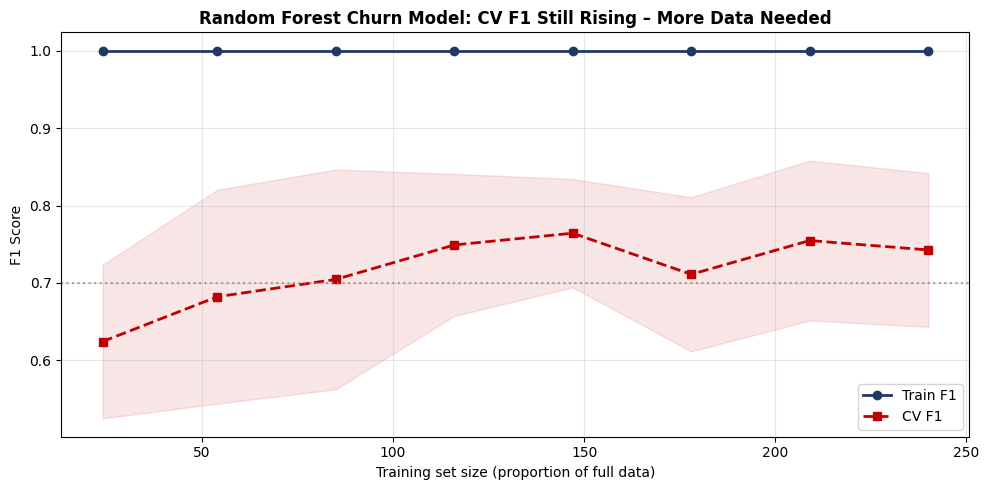

Bonus – Learning curve saved as 'Day114_LearningCurve.png'

Interpretation: The CV F1 curve has not plateaued; it continues to rise with more data.
The large gap between train and CV F1 indicates high variance (overfitting).


In [14]:
# =============================================================================
# ★ BONUS – Learning curve for RandomForestClassifier
# Goal: Assess whether more training data would improve performance.
# Method: learning_curve with StratifiedKFold, plot train and CV F1.
# =============================================================================

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_scaled, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#1F3864', lw=2, label='Train F1')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.1, color='#1F3864')
plt.plot(train_sizes, test_mean, 's--', color='#C00000', lw=2, label='CV F1')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 alpha=0.1, color='#C00000')
plt.axhline(y=0.70, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('Training set size (proportion of full data)')
plt.ylabel('F1 Score')
plt.title('Random Forest Churn Model: CV F1 Still Rising – More Data Needed', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Day114_LearningCurve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bonus – Learning curve saved as 'Day114_LearningCurve.png'")
print("\nInterpretation: The CV F1 curve has not plateaued; it continues to rise with more data.")
print("The large gap between train and CV F1 indicates high variance (overfitting).")
print("Collecting additional customer records would improve the model's generalisation.")

---
## Section 5 — Scoring Rubric

| Part | Task | Pts | Pass Criteria |
|------|------|-----|---------------|
| A | A1 Shape + churn rate | 5 | shape (300,8), rate printed |
| A | A2 Baseline 3 metrics | 5 | Accuracy, F1, ROC-AUC all visible |
| A | A3 Train/test class distribution | 5 | Both rates printed + yes/no verdict |
| B | B1 KFold(5) all 5 scores + mean±std | 7 | Correct output |
| B | B2 KFold(10) + comparison | 7 | 10 scores + comparison printed |
| B | B3 cross_validate train+test + verdict | 6 | Both printed + gap stated + verdict |
| C | C1 StratKFold(5) mean±std | 5 | Correct output |
| C | C2 Churn rate per fold | 5 | All 5 folds printed, ±3% confirmed |
| C | C3 KFold vs SKF table + recommendation | 5 | Table + written rationale citing imbalance |
| D | D1 cross_validate 3 metrics LR | 8 | All 3 metrics, train+test, mean±std |
| D | D2 LR vs RF comparison | 7 | Side-by-side, winner marked per metric |
| E | E1 Three-model summary sorted by F1 | 8 | All 3 models × 3 metrics, sorted |
| E | E2 NRA recommendation | 7 | Number (computed), Reason (F1/imbalance), Action (model + std condition) |
| ★ | Learning curve | 10 | Train+CV lines, insight title, PNG saved |
| **Total** | | **80 + 10★** | |

---

### Submission Notes
1. All cells run top-to-bottom, outputs visible
2. E2 NRA must use **printed numbers from E1** — not hand-typed estimates
3. Bonus title must state a business insight (variance / data volume / plateau)
4. GitHub commit: `feat: Day114 - Cross-Validation KFold StratifiedKFold - Month6`

---

### Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| 101–112 | Stats → PCA | 80/80 + 10★ each |
| 113 | Week 5 Mini-Project | — |
| **114** | **Cross-Validation** | **Pending** |

---

### Interview Frame — Day 114

> *"How do you make sure your model evaluation is reliable?"*

**Answer:** *"I use StratifiedKFold cross-validation — 5 folds as standard. A single train/test split gives one score that depends on which rows happened to land in the test set. Cross-validation runs the full evaluation k times and reports mean ± std. For an imbalanced churn dataset at 24%, stratification is critical — without it, individual folds may not reflect the true class ratio and F1 becomes unstable. My output format is: 'XGBoost: F1 = 0.77 ± 0.07 across 5 stratified folds.' That number, with its uncertainty, is what I put in front of a client or CTO. A single split score is not defensible."*

---

### Key Takeaway — Day 114

**A single train/test score is an anecdote. A cross-validated mean ± std is evidence.**

The train-test F1 gap is the diagnostic every production ML engineer reads first. Tree models with Train F1 = 1.0 and Test F1 = 0.74 are telling you they memorised the training set — that gap doesn't show up in a single split, but it appears immediately in `cross_validate`. StratifiedKFold is the default for any imbalanced classification task — which describes nearly every real business problem.
